### Md. Redoy Siddik

### redoyredit@gmail.com

### Necessary imports

In [ ]:
!pip install ydata-profiling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gradio as gr

from ydata_profiling import ProfileReport
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### 1. Dataset Load

In [ ]:
df = pd.read_csv('insurance.csv')

display(df.head())
print('Shape:', df.shape)
print('Columns:', df.columns)
print('Info:', df.info())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Shape: (1338, 7)
Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
Info: None


In [ ]:
df = pd.read_csv('insurance.csv')

profile = ProfileReport(df, title='Medical Insurance Cost Prediction', explorative=True)

profile.to_file('ydata.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 16.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### 2. Data Preprocessing

In [ ]:
# Checking missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


No missing values. So we don't need to fill any cells.

In [ ]:
# Removing duplicate values

print('No. of duplicate rows before:', df.duplicated().sum())

df.drop_duplicates(inplace=True)

print('No. of duplicate rows after:', df.duplicated().sum())

No. of duplicate rows before: 1
No. of duplicate rows after: 0


There was a duplicate row. So we removed the duplicate row.

In [ ]:
# Separating Feature and target
X = df.drop('charges', axis=1)
y = df['charges']

# Separating Numerical and Categorical Columns
num_col = X.select_dtypes(include=np.number).columns
cat_col = X.select_dtypes(include='object').columns

print('Numerical Columns:', num_col)
print('Categorical Columns:', cat_col)

Numerical Columns: Index(['age', 'bmi', 'children'], dtype='object')
Categorical Columns: Index(['sex', 'smoker', 'region'], dtype='object')


In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

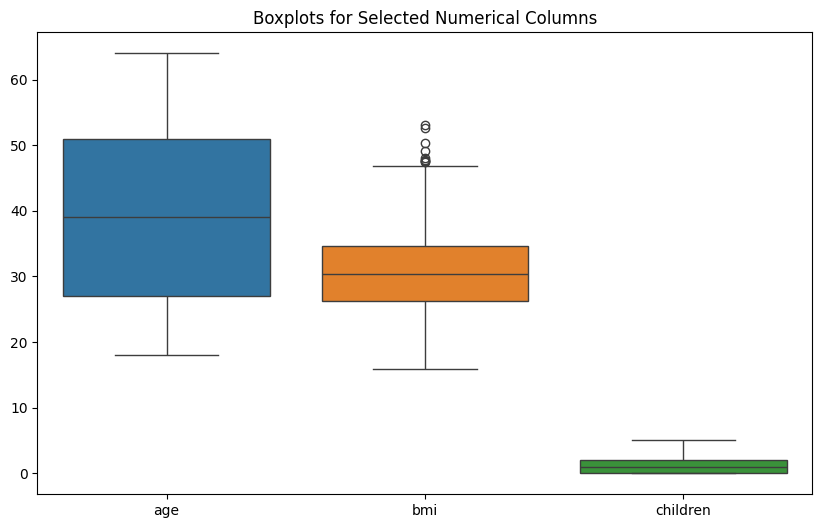

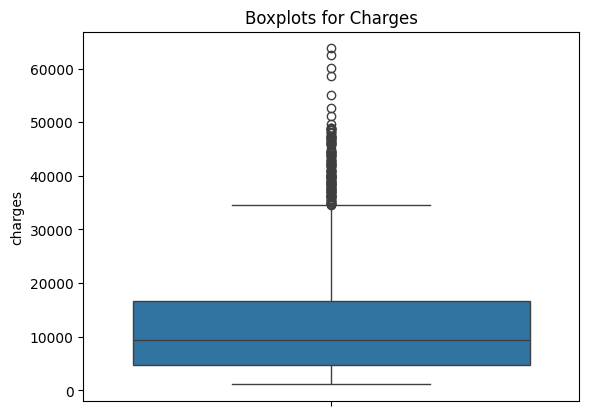

In [ ]:
# Outlier Detection

numeric_cols = ['age', 'bmi', 'children']

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[num_col])
plt.title('Boxplots for Selected Numerical Columns')
plt.show()

sns.boxplot(data=df['charges'])
plt.title('Boxplots for Charges')
plt.show()

- Here we can see 'bmi' and 'charges' have some outliers.

- For 'bmi', we will use IQR to detect and handle the outlier.

- For 'charges', we will log transformation as it is our target column.

In [ ]:
# Handling Outliers
df_temp = pd.concat([X_train, y_train], axis=1)

# IQR method for 'bmi'

q1 = df_temp['bmi'].quantile(0.25)
q3 = df_temp['bmi'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_temp = df_temp[(df_temp['bmi'] >= lower_bound) & (df_temp['bmi'] <= upper_bound)]

print('Shape after outlier handling:', df.shape)

# Train dataset creation for the oulier handled dataset

X_train = df_temp.drop('charges', axis=1)
y_train = df_temp['charges']

Shape after outlier handling: (1337, 7)


Here outliers handled for the 'bmi' column.

In [ ]:
# Log tranformation for the Target column

y_train = np.log(y_train + 1)

Here we used log transformation for the target column, as higher insurance costs are realistic.

Numerical Pipeline

In [ ]:
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

Categorical Pipeline

In [ ]:
cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]
)

Preprocessor Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col),
        ('cat', cat_transformer, cat_col)
    ]
)

### 3. Pipeline Creation

In [ ]:
# Base Models

ref_lr = LinearRegression()
ref_rf = RandomForestRegressor(n_estimators=100, random_state=42)
ref_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)

In [ ]:
# Voting Regressor

voting_reg = VotingRegressor(
    estimators=[
        ('lr', ref_lr),
        ('rf', ref_rf),
        ('gb', ref_gb)
    ]
)

In [ ]:
# Stacking regressor

stacking_reg = StackingRegressor(
    estimators=[
        ('lr', ref_lr),
        ('rf', ref_rf),
        ('gb', ref_gb)
    ],
    final_estimator = Ridge()
)

In [ ]:
# Storing all models

model_to_train = {
    'Linear Regression': ref_lr,
    'Random Forest': ref_rf,
    'Gradient Boosting': ref_gb,
    'Voting Regressor': voting_reg,
    'Stacking Regressor': stacking_reg
}

### Q4. Primary Model Selection

In [ ]:
result = []

for name, model in model_to_train.items():
    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_pred = np.exp(y_pred) - 1

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    result.append({
        'Model Name': name,
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

result_df = pd.DataFrame(result).sort_values(by='R2 Score', ascending=False)
best_model_name = result_df.iloc[0]['Model Name']
best_model_obj = model_to_train[best_model_name]
display(best_model_name)

'Stacking Regressor'

Among all the models, "Stacking Regressor" got the highest R² score and lowest prediction error. Therefore, it is selected as the primary model.

### Q5. Model Training

In [ ]:
final_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', best_model_obj)
    ]
)

final_pipe.fit(X_train, y_train)
y_final_pred = final_pipe.predict(X_test)

y_final_pred = np.exp(y_final_pred) - 1

r2 = r2_score(y_test, y_final_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
mae = mean_absolute_error(y_test, y_final_pred)

print('R2:', r2)
print('RMSE:', rmse)
print('MAE:', mae)

R2: 0.9004320130892267
RMSE: 4277.408254915517
MAE: 2103.3407502062278


### Q6. Cross-Validation

In [ ]:
cv_scores = cross_val_score(
    final_pipe,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print('CV Score:', cv_scores)
print('CV Average:', cv_scores.mean())
print('CV Standard Deviation:', cv_scores.std())

CV Score: [0.76058718 0.85707591 0.79010302 0.81110875 0.83303735]
CV Average: 0.8103824409019191
CV Standard Deviation: 0.03342117839893502


### 7. Hyperparameter Tuning

In [ ]:
best_model_name = result_df.iloc[0]['Model Name']
best_model_obj = model_to_train[best_model_name]

print(best_model_name)

Stacking Regressor


In [ ]:
# Creating final pipeline

final_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', best_model_obj)
    ])

for param in final_pipe.get_params().keys():
    print(param)

memory
steps
transform_input
verbose
preprocessor
model
preprocessor__force_int_remainder_cols
preprocessor__n_jobs
preprocessor__remainder
preprocessor__sparse_threshold
preprocessor__transformer_weights
preprocessor__transformers
preprocessor__verbose
preprocessor__verbose_feature_names_out
preprocessor__num
preprocessor__cat
preprocessor__num__memory
preprocessor__num__steps
preprocessor__num__transform_input
preprocessor__num__verbose
preprocessor__num__imputer
preprocessor__num__scaler
preprocessor__num__imputer__add_indicator
preprocessor__num__imputer__copy
preprocessor__num__imputer__fill_value
preprocessor__num__imputer__keep_empty_features
preprocessor__num__imputer__missing_values
preprocessor__num__imputer__strategy
preprocessor__num__scaler__copy
preprocessor__num__scaler__with_mean
preprocessor__num__scaler__with_std
preprocessor__cat__memory
preprocessor__cat__steps
preprocessor__cat__transform_input
preprocessor__cat__verbose
preprocessor__cat__imputer
preprocessor__cat

In [ ]:
# Defining the Grid

param_grid = {
    'model__rf__n_estimators': [10, 100, 200],
    'model__rf__max_depth': [10, 20],
    'model__gb__n_estimators': [10, 100, 200],
    'model__gb__learning_rate': [0.01, 0.1],
    'model__final_estimator__alpha': [0.1, 1.0, 10.0]
}

In [ ]:
# Grid Search CV Configuration

grid_search = GridSearchCV(
    estimator = final_pipe,
    param_grid = param_grid,
    cv=5,
    scoring='r2',
    n_jobs = -1,
    verbose = 2
)

In [ ]:
# Training

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',...
                                                                       RandomForestRegressor(random_state=42)),
                                                                      ('gb',
                                                                       GradientBoostingRegressor(random_state=42))],
                                                          final_estimator=Ridge()))]),
             n_jobs=-1,
             param_grid={'model__final_estimator__alpha': [0.1, 1.0, 10.0],
                         'model__gb__learning_rate': [0.01, 0.1],
                         'model__gb__n_estimators': [10, 100, 200],
                         'model__rf__max_depth': [10, 20],
                         'model__rf__n_estimators': [10, 100, 200]},
             scoring='r2', verbose=2)

In [ ]:
print('Best Grid Search Score:', grid_search.best_score_)
print('Best Grid Search Params:', grid_search.best_params_)

Best Grid Search Score: 0.8160519520379941
Best Grid Search Params: {'model__final_estimator__alpha': 1.0, 'model__gb__learning_rate': 0.01, 'model__gb__n_estimators': 200, 'model__rf__max_depth': 10, 'model__rf__n_estimators': 10}


### Q8. Best Model Selection

In [ ]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

y_pred = np.exp(y_pred) - 1

### Q9. Model Performance Evaluation

In [ ]:
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

print('R2:', r2)
print('RMSE:', rmse)
print('MAE:', mae)

R2: 0.9066399252180125
RMSE: 4141.917415946476
MAE: 1973.2424007528418


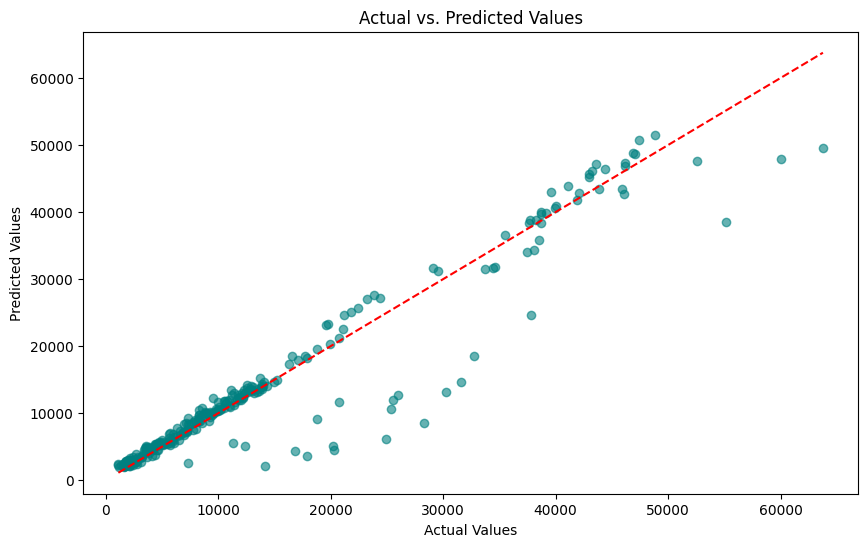

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(x = y_test, y = y_pred, alpha = 0.6, color = 'teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

In [ ]:
# Saving the model

file_name = 'insurance_model.pkl'

with open(file_name, 'wb') as file:
    pickle.dump(best_model, file)

### Q10. Web Interface with Gradio

In [ ]:
# Loading the model

with open('insurance_model.pkl', 'rb') as file:
    model = pickle.load(file)

In [ ]:
# Gradio web app

def predict_insurance(age, sex, bmi, children, smoker, region):
    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    prediction = model.predict(input_data)
    prediction = np.exp(prediction) - 1

    return prediction[0]

inputs=[
    gr.Number(label='Age'),
    gr.Radio(['male', 'female'], label='Sex'),
    gr.Number(label='BMI'),
    gr.Slider(minimum=0, maximum=5, step=1, label='Number of Children'),
    gr.Radio(['yes', 'no'], label='Smoker'),
    gr.Radio(['southwest', 'southeast', 'northwest', 'northeast'], label='Region')
]

app = gr.Interface(
    fn=predict_insurance,
    inputs=inputs,
    outputs=gr.Number(label='Insurance Cost'),
    title='Medical Insurance Cost Prediction'
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d8d6154261774e071.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
